# Выбор ARIMA на validation

Ноутбук выполняет двухступенчатый выбор ARIMA для прогноза логарифмической доходности следующего торгового дня. Кандидаты ранжируются по BIC только на train, три лучших порядка каждого тикера проходят ежедневный expanding-window backtest на validation, после чего победитель сравнивается с `naive_zero`. Final test не используется для обучения, выбора или расчёта метрик.

In [1]:
import sys
import warnings
from functools import partial
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, clear_output, display
from statsmodels.tools.sm_exceptions import ConvergenceWarning, EstimationWarning

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from evaluation.contracts import BPS_FACTOR  # noqa: E402
from evaluation.loading import load_processed_snapshot  # noqa: E402
from evaluation.metrics import calculate_metrics  # noqa: E402
from evaluation.pipeline import build_predictions  # noqa: E402
from evaluation.selection import select_arima_candidates  # noqa: E402
from evaluation.walk_forward import build_walk_forward_predictions  # noqa: E402
from models.arima import (  # noqa: E402
    build_arima_fitters,
    search_arima_orders,
    shortlist_arima_orders,
)
from models.naive import NaiveModel  # noqa: E402

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=EstimationWarning)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

EXPECTED_TICKERS = {"SPY", "AAPL", "JPM", "XOM"}
P_VALUES = tuple(range(6))
D_VALUES = (0,)
Q_VALUES = tuple(range(6))
SHORTLIST_SIZE = 3
PROGRESS_UPDATE_INTERVAL = 25
CANDIDATES_PER_TICKER = len(P_VALUES) * len(D_VALUES) * len(Q_VALUES)
started_at = perf_counter()

## Проверенный снимок

Загрузчик сверяет CSV с отслеживаемым манифестом. Даты final test используются только как множество для проверки отсутствия пересечения; сами test-наблюдения и их доходности далее не отображаются.

In [2]:
snapshot = load_processed_snapshot(PROJECT_ROOT / "data" / "processed")
dataset = snapshot.dataset
test_target_dates = set(dataset.loc[dataset["split"].eq("test"), "target_date"])

assert set(dataset["ticker"]) == EXPECTED_TICKERS
dataset.loc[dataset["split"].ne("test")].groupby(["ticker", "split"], sort=True).agg(
    observations=("target_return", "size"),
    first_target_date=("target_date", "min"),
    last_target_date=("target_date", "max"),
)

observations first_target_date last_target_date
ticker split                                                      
AAPL   train               2515        2006-01-05       2015-12-31
       validation          1006        2016-01-04       2019-12-31
JPM    train               2515        2006-01-05       2015-12-31
       validation          1006        2016-01-04       2019-12-31
SPY    train               2515        2006-01-05       2015-12-31
       validation          1006        2016-01-04       2019-12-31
XOM    train               2515        2006-01-05       2015-12-31
       validation          1006        2016-01-04       2019-12-31

## Train-поиск и диагностика сходимости

Для каждого тикера оцениваются 36 порядков `ARIMA(p, 0, q)`, где `p` и `q` принимают значения от 0 до 5. Поиск использует только train. Неудачные и несошедшиеся модели остаются в полной таблице со статусом, но не допускаются в shortlist.

In [3]:
search_results = search_arima_orders(
    dataset,
    p_values=P_VALUES,
    d_values=D_VALUES,
    q_values=Q_VALUES,
)
candidate_counts = (
    search_results.groupby(["ticker", "status"], sort=True)
    .size()
    .rename("candidates")
    .reset_index()
)

assert search_results.groupby("ticker").size().eq(CANDIDATES_PER_TICKER).all()
candidate_counts

,ticker,status,candidates
0,AAPL,not_converged,4
1,AAPL,ok,32
2,JPM,not_converged,6
3,JPM,ok,30
4,SPY,not_converged,4
5,SPY,ok,32
6,XOM,not_converged,8
7,XOM,ok,28


## BIC shortlist

Из кандидатов со статусом `ok`, подтверждённой сходимостью и конечными информационными критериями выбираются три минимальных BIC отдельно для каждого тикера. BIC применяется только для предварительного сокращения пространства моделей.

In [4]:
shortlist = shortlist_arima_orders(search_results, size=SHORTLIST_SIZE)

assert shortlist.groupby("ticker").size().eq(SHORTLIST_SIZE).all()
assert shortlist["status"].eq("ok").all()
assert shortlist["converged"].all()
assert np.isfinite(shortlist[["aic", "bic"]].to_numpy()).all()

shortlist.loc[:, ["ticker", "bic_rank", "model", "p", "d", "q", "aic", "bic"]].round(
    {"aic": 3, "bic": 3}
)

,ticker,bic_rank,model,p,d,q,aic,bic
0,AAPL,1,arima_bic_1,0,0,0,-12145.727,-12134.067
1,AAPL,2,arima_bic_2,1,0,0,-12143.728,-12126.238
2,AAPL,3,arima_bic_3,0,0,1,-12143.727,-12126.237
3,JPM,1,arima_bic_1,1,0,1,-10988.412,-10965.092
4,JPM,2,arima_bic_2,0,0,1,-10970.704,-10953.214
5,JPM,3,arima_bic_3,1,0,3,-10987.205,-10952.225
6,SPY,1,arima_bic_1,2,0,0,-14729.217,-14705.897
7,SPY,2,arima_bic_2,0,0,2,-14728.459,-14705.139
8,SPY,3,arima_bic_3,2,0,1,-14728.211,-14699.061
9,XOM,1,arima_bic_1,2,0,0,-13776.620,-13753.300


## Ежедневный expanding-window validation backtest

Каждый из трёх BIC-кандидатов ежедневно переобучается на доступной к origin date истории своего тикера. История постепенно включает уже наблюдённую часть validation, но исключает `target_return` и весь final test.

In [5]:
fitters = build_arima_fitters(shortlist)
validation_observations = int(dataset["split"].eq("validation").sum())
progress_state = {
    model_name: {"completed": 0, "total": validation_observations} for model_name in fitters
}
progress_started_at = perf_counter()


def report_progress(model_name: str, completed: int, total: int) -> None:
    progress_state[model_name] = {"completed": completed, "total": total}
    should_update = (
        completed == 1 or completed == total or completed % PROGRESS_UPDATE_INTERVAL == 0
    )
    if not should_update:
        return

    progress_frame = pd.DataFrame.from_dict(progress_state, orient="index")
    progress_frame.index.name = "model"
    progress_frame["percent"] = progress_frame["completed"] / progress_frame["total"] * 100
    overall_completed = int(progress_frame["completed"].sum())
    overall_total = int(progress_frame["total"].sum())
    elapsed_seconds = perf_counter() - progress_started_at
    forecasts_per_second = overall_completed / elapsed_seconds
    remaining_minutes = (overall_total - overall_completed) / forecasts_per_second / 60

    clear_output(wait=True)
    display(progress_frame.round({"percent": 1}))
    print(
        f"Всего: {overall_completed}/{overall_total} | "
        f"прошло {elapsed_seconds / 60:.1f} мин | "
        f"примерно осталось {remaining_minutes:.1f} мин"
    )


candidate_frames = []
for model_name, fitter in fitters.items():
    candidate_frames.append(
        build_walk_forward_predictions(
            dataset,
            fitter,
            progress=partial(report_progress, model_name),
        )
    )
candidate_predictions = pd.concat(candidate_frames, ignore_index=True)
baseline_predictions = (
    build_predictions(dataset, NaiveModel())
    .loc[lambda frame: frame["split"].eq("validation")]
    .reset_index(drop=True)
)
predictions = pd.concat([baseline_predictions, candidate_predictions], ignore_index=True)

assert predictions["split"].eq("validation").all()
assert not predictions["target_date"].isin(test_target_dates).any()
assert set(candidate_predictions["model"]) == set(fitters)
expected_validation_counts = baseline_predictions.groupby("ticker").size()
for model_name in fitters:
    model_counts = (
        candidate_predictions.loc[candidate_predictions["model"].eq(model_name)]
        .groupby("ticker")
        .size()
    )
    assert model_counts.equals(expected_validation_counts)

predictions.groupby(["model", "ticker"], sort=True).agg(
    observations=("actual_return", "size"),
    first_target_date=("target_date", "min"),
    last_target_date=("target_date", "max"),
)

,completed,total,percent
model,,,
arima_bic_1,4024,4024,100.0
arima_bic_2,4024,4024,100.0
arima_bic_3,4024,4024,100.0


Всего: 12072/12072 | прошло 35.7 мин | примерно осталось 0.0 мин


observations first_target_date last_target_date
model       ticker                                                 
arima_bic_1 AAPL            1006        2016-01-04       2019-12-31
            JPM             1006        2016-01-04       2019-12-31
            SPY             1006        2016-01-04       2019-12-31
            XOM             1006        2016-01-04       2019-12-31
arima_bic_2 AAPL            1006        2016-01-04       2019-12-31
            JPM             1006        2016-01-04       2019-12-31
            SPY             1006        2016-01-04       2019-12-31
            XOM             1006        2016-01-04       2019-12-31
arima_bic_3 AAPL            1006        2016-01-04       2019-12-31
            JPM             1006        2016-01-04       2019-12-31
            SPY             1006        2016-01-04       2019-12-31
            XOM             1006        2016-01-04       2019-12-31
naive_zero  AAPL            1006        2016-01-04       2019-12-31
            JPM             1006        2016-01-04       2019-12-31
            SPY             1006        2016-01-04       2019-12-31
            XOM             1006        2016-01-04       2019-12-31

## Выбор порядка на validation

Победитель каждого тикера определяется по неокруглённым validation-метрикам: MAE, RMSE, сложности `p + d + q`, train BIC, затем `p` и `q`. Поэтому следующая таблица описывает model selection, а не независимую оценку обобщающей способности.

In [6]:
selection = select_arima_candidates(predictions, shortlist)
selected_orders = selection.orders
selected_predictions = selection.predictions

assert set(selected_orders["ticker"]) == {"SPY", "AAPL", "JPM", "XOM"}
assert (
    selected_predictions.groupby("ticker")
    .size()
    .equals(baseline_predictions.groupby("ticker").size())
)

selection.candidate_metrics.round(
    {
        "mae_bps": 3,
        "rmse_bps": 3,
        "rel_mae": 4,
        "oos_r2": 4,
        "directional_accuracy": 4,
        "bic": 3,
    }
)

,split,ticker,model,observations,mae_bps,rmse_bps,rel_mae,oos_r2,directional_accuracy,p,d,q,bic,bic_rank
0,validation,AAPL,arima_bic_1,1006,105.899,153.525,0.9960,0.0046,0.5437,0,0,0,-12134.067,1
1,validation,AAPL,arima_bic_2,1006,105.912,153.545,0.9961,0.0043,0.5437,1,0,0,-12126.238,2
2,validation,AAPL,arima_bic_3,1006,105.913,153.545,0.9961,0.0043,0.5437,0,0,1,-12126.237,3
3,validation,JPM,arima_bic_1,1006,93.318,131.701,1.0157,-0.0208,0.4980,1,0,1,-10965.092,1
4,validation,JPM,arima_bic_2,1006,92.351,130.760,1.0051,-0.0062,0.4970,0,0,1,-10953.214,2
5,validation,JPM,arima_bic_3,1006,93.219,131.651,1.0146,-0.0200,0.5129,1,0,3,-10952.225,3
6,validation,SPY,arima_bic_1,1006,54.814,81.284,0.9996,0.0025,0.5229,2,0,0,-14705.897,1
7,validation,SPY,arima_bic_2,1006,54.813,81.319,0.9996,0.0016,0.5249,0,0,2,-14705.139,2
8,validation,SPY,arima_bic_3,1006,54.824,81.236,0.9998,0.0037,0.5268,2,0,1,-14699.061,3
9,validation,XOM,arima_bic_1,1006,84.205,115.589,1.0101,-0.0316,0.5169,2,0,0,-13753.300,1


### Выбранные порядки

In [7]:
selected_orders.round({"bic": 3})

,ticker,p,d,q,bic,bic_rank,model
0,AAPL,0,0,0,-12134.067,1,arima_bic_1
1,JPM,0,0,1,-10953.214,2,arima_bic_2
2,SPY,0,0,2,-14705.139,2,arima_bic_2
3,XOM,2,0,1,-13746.827,3,arima_bic_3


## Выбранная ARIMA против `naive_zero`

Выбранные по каждому тикеру прогнозы получают единое имя `arima` и сравниваются с baseline на строго совпадающих validation-наблюдениях. Строка `ALL` рассчитывается непосредственно по объединённым ошибкам.

In [8]:
final_predictions = pd.concat([baseline_predictions, selected_predictions], ignore_index=True)
final_metrics = calculate_metrics(final_predictions)
final_metrics.round(
    {
        "mae_bps": 3,
        "rmse_bps": 3,
        "rel_mae": 4,
        "oos_r2": 4,
        "directional_accuracy": 4,
    }
)

,split,ticker,model,observations,mae_bps,rmse_bps,rel_mae,oos_r2,directional_accuracy
0,validation,AAPL,arima,1006,105.899,153.525,0.9960,0.0046,0.5437
1,validation,JPM,arima,1006,92.351,130.760,1.0051,-0.0062,0.4970
2,validation,SPY,arima,1006,54.813,81.319,0.9996,0.0016,0.5249
3,validation,XOM,arima,1006,84.194,115.552,1.0099,-0.0309,0.5109
4,validation,ALL,arima,4024,84.314,123.119,1.0025,-0.0064,0.5191
5,validation,AAPL,naive_zero,1006,106.326,153.878,1.0000,0.0000,0.0020
6,validation,JPM,naive_zero,1006,91.878,130.354,1.0000,0.0000,0.0060
7,validation,SPY,naive_zero,1006,54.834,81.386,1.0000,0.0000,0.0040
8,validation,XOM,naive_zero,1006,83.367,113.807,1.0000,0.0000,0.0040
9,validation,ALL,naive_zero,4024,84.101,122.726,1.0000,0.0000,0.0040


## Распределения ошибок

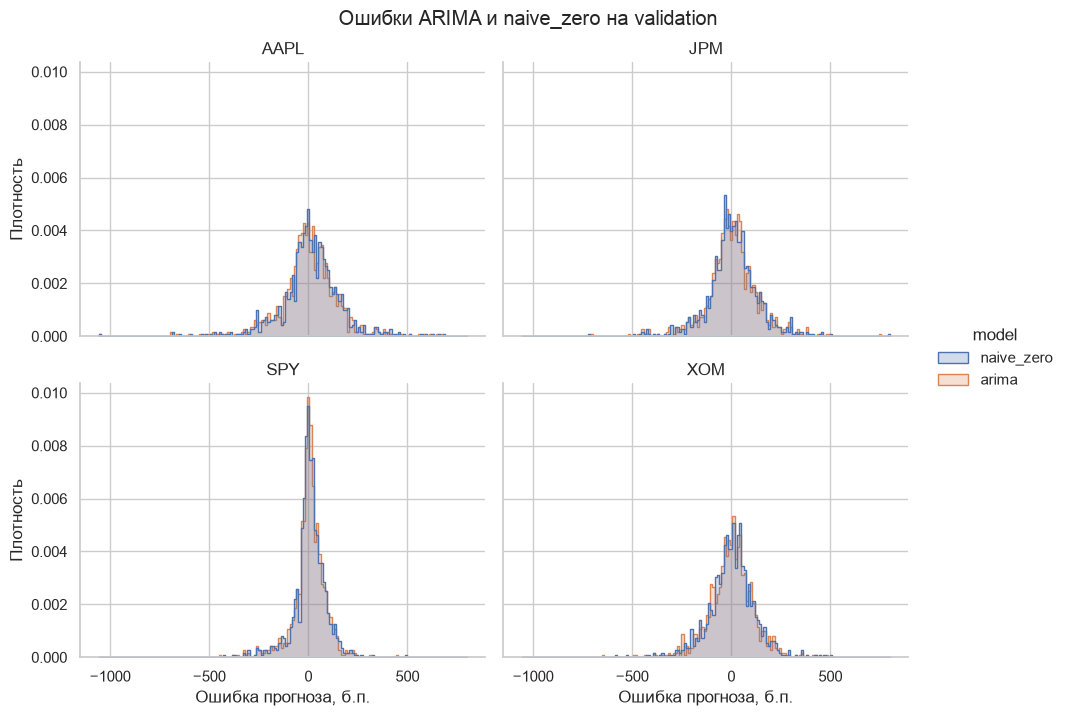

In [9]:
errors = final_predictions.assign(
    error_bps=(final_predictions["actual_return"] - final_predictions["predicted_return"])
    * BPS_FACTOR
)
grid = sns.displot(
    data=errors,
    x="error_bps",
    hue="model",
    col="ticker",
    col_wrap=2,
    kind="hist",
    element="step",
    stat="density",
    common_norm=False,
    height=3.5,
    aspect=1.35,
)
grid.set_axis_labels("Ошибка прогноза, б.п.", "Плотность")
grid.set_titles("{col_name}")
grid.figure.suptitle("Ошибки ARIMA и naive_zero на validation", y=1.02)
plt.show()

## Остаточная диагностика

Среднее, стандартное отклонение, квантили и автокорреляция первого лага дают компактное описание остатков. Это диагностические показатели, а не дополнительный критерий настройки модели.

In [10]:
residual_diagnostics = (
    errors.sort_values(["model", "ticker", "target_date"])
    .groupby(["model", "ticker"], sort=True)["error_bps"]
    .agg(
        observations="size",
        mean="mean",
        std="std",
        median="median",
        q05=lambda values: values.quantile(0.05),
        q95=lambda values: values.quantile(0.95),
        lag1_autocorrelation=lambda values: values.autocorr(lag=1),
    )
    .reset_index()
)
residual_diagnostics.round(3)

,model,ticker,observations,mean,std,median,q05,q95,lag1_autocorrelation
0,arima,AAPL,1006,1.669,153.592,0.518,-246.165,222.797,0.016
1,arima,JPM,1006,5.268,130.719,3.950,-209.198,215.675,0.091
2,arima,SPY,1006,2.689,81.315,4.632,-144.602,121.996,0.033
3,arima,XOM,1006,-1.983,115.592,3.709,-188.935,178.570,0.132
4,naive_zero,AAPL,1006,10.872,153.570,9.759,-237.149,231.772,0.016
5,naive_zero,JPM,1006,8.472,130.143,5.387,-197.984,216.625,-0.014
6,naive_zero,SPY,1006,5.315,81.252,5.905,-135.936,127.639,-0.054
7,naive_zero,XOM,1006,0.485,113.863,3.695,-193.741,172.536,-0.018


## Интерпретация и границы вывода

- BIC на train сокращает пространство кандидатов, но не определяет окончательный порядок.
- Окончательные порядки выбраны по validation MAE с заранее заданными критериями разрешения равенств.
- Сравнение с `naive_zero` на validation характеризует этап настройки и не является независимой оценкой качества.
- Остаточная диагностика помогает обнаружить систематическую ошибку и оставшуюся линейную зависимость, но не заменяет final-test оценку.
- Final test остаётся закрытым. Итоговые выводы о качестве и обобщающей способности ARIMA будут сформулированы только после фиксации всех моделей и однократного открытия test.

In [11]:
elapsed_minutes = (perf_counter() - started_at) / 60
arima_pooled = final_metrics.loc[
    final_metrics["ticker"].eq("ALL") & final_metrics["model"].eq("arima")
].iloc[0]
display(
    Markdown(
        f"**Время выполнения:** {elapsed_minutes:.1f} мин. "
        f"На validation объединённая ARIMA получила MAE "
        f"{arima_pooled['mae_bps']:.3f} б.п. и относительную MAE "
        f"{arima_pooled['rel_mae']:.4f} к `naive_zero`. "
        "Эти значения использованы для выбора модели; final test не открывался."
    )
)

**Время выполнения:** 36.8 мин. На validation объединённая ARIMA получила MAE 84.314 б.п. и относительную MAE 1.0025 к `naive_zero`. Эти значения использованы для выбора модели; final test не открывался.